# Notebook 01 — Explore TuSimple Dataset

This notebook is the entry point for understanding our data. We do four things:

1. **Load the dataset** using our custom `TuSimpleDataset` class
2. **Read one image with OpenCV** and understand the BGR/RGB convention
3. **Inspect the annotation format** — how lanes are stored as row-anchor coordinates
4. **Draw the ground-truth lanes** on the image to visualize what "correct" looks like

By the end you will have:
- A working understanding of how the dataset is structured
- Confirmation that the loader, OpenCV, and Matplotlib all work end-to-end
- A visual sanity check that the annotations match real lanes in the image

This notebook does **not** do any actual lane detection — it is purely for exploration and for sanity-checking the pipeline foundation.

## 1. Imports and setup

We import the standard scientific Python stack plus our custom loader. The `%matplotlib inline` magic command tells Jupyter to render plots directly below each cell instead of opening external windows (which wouldn't work in Codespaces anyway).

In [1]:
"""Notebook 01: Explore TuSimple dataset and visualize ground-truth lanes."""

import sys
from pathlib import Path

# Add src/ to import path so we can use our loader
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd() / "src"))  # in case CWD is repo root

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tusimple_loader import TuSimpleDataset

# Inline plots
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100

print("Imports OK")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

Imports OK
OpenCV version: 4.9.0
NumPy version: 1.26.4


## 2. Load the dataset

We instantiate `TuSimpleDataset` pointing at our 100-frame subset. The class reads `test_label_subset.json` and resolves each annotation to a real image path on disk. The check `len(dataset.existing_only())` confirms that every annotation has a corresponding image file — if this number is less than `len(dataset)`, some images are missing.

In [2]:
# Find the project root (where the notebook is run from)
# In Codespaces, CWD is usually /workspaces/lane-detection-cv
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

print(f"Project root: {project_root}")

dataset = TuSimpleDataset(
    annotation_file=project_root / "data/tusimple/test_subset/test_label_subset.json",
    image_root=project_root / "data/tusimple/test_subset",
)

print(f"Total annotations: {len(dataset)}")
print(f"Images on disk: {len(dataset.existing_only())}")

Project root: /workspaces/lane-detection-cv
Total annotations: 100
Images on disk: 100


## 3. Read and display one image

This is your first hands-on encounter with OpenCV. A few important details:

- **Images are NumPy arrays.** Shape `(720, 1280, 3)` means 720 rows × 1280 columns × 3 colour channels.
- **`uint8` type means each pixel value is 0–255.** Black is 0, white is 255.
- **OpenCV uses BGR order.** Most other libraries (Matplotlib, PIL) use RGB. We convert with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` before displaying. Forgetting this is one of the most common OpenCV bugs — your image displays with red/blue swapped (sky looks orange).

raw_file:     clips/0530/1492626760788443246_0/20.jpg
image path:   /workspaces/lane-detection-cv/data/tusimple/test_subset/clips/0530/1492626760788443246_0/20.jpg
num lanes:    4
visible:      4
image exists: True

Image shape (height, width, channels): (720, 1280, 3)
Image dtype: uint8
Pixel value range: 0 to 255


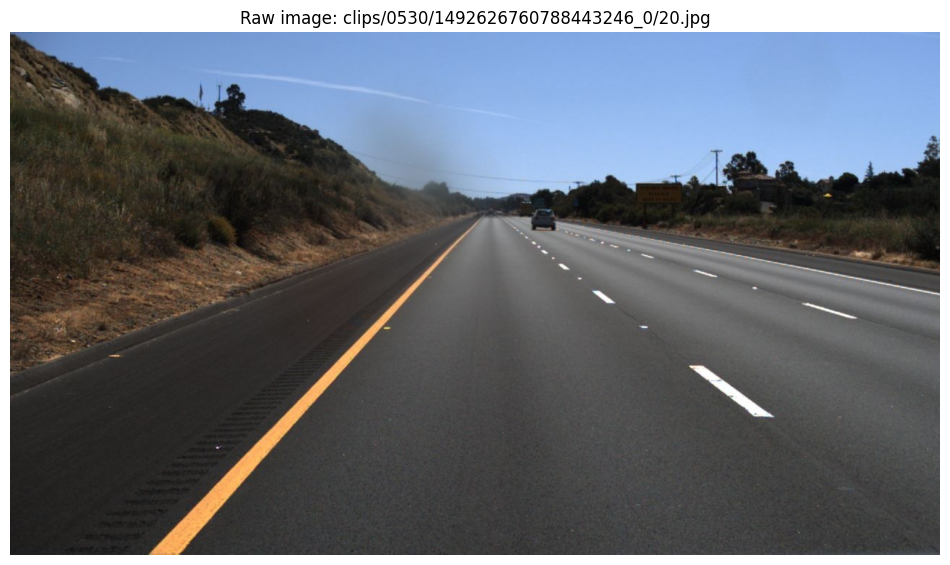

In [3]:
# Pick a sample to inspect
sample = dataset[0]

print(f"raw_file:     {sample.raw_file}")
print(f"image path:   {sample.image_path}")
print(f"num lanes:    {sample.num_lanes}")
print(f"visible:      {sample.num_visible_lanes}")
print(f"image exists: {sample.image_path.exists()}")

# Read the image with OpenCV
# IMPORTANT: OpenCV reads images as BGR (not RGB!) — a famous OpenCV quirk
image_bgr = cv2.imread(str(sample.image_path))
print(f"\nImage shape (height, width, channels): {image_bgr.shape}")
print(f"Image dtype: {image_bgr.dtype}")
print(f"Pixel value range: {image_bgr.min()} to {image_bgr.max()}")

# Convert BGR → RGB so matplotlib displays it correctly
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display
plt.imshow(image_rgb)
plt.title(f"Raw image: {sample.raw_file}")
plt.axis("off")
plt.show()

## 4. Examine the annotation format

TuSimple uses a **row-anchor representation**: instead of storing lanes as free-form (x, y) curves, it samples each lane at fixed y-coordinates (rows) and stores only the x-coordinate at each.

- `h_samples` is the same for every frame: `[160, 170, 180, ..., 710]` — 56 rows spaced 10 pixels apart, covering the road region.
- `lanes[i]` is the i-th lane's list of x-coordinates, one per y in `h_samples`.
- Special value `-2` means "this lane is not visible at this y" — typically because it's above where the lane starts (vanishing point) or off the side of the image.

This format is efficient (lanes are mostly vertical, so one x-per-y is natural) and is also used by recent SOTA methods like Ultra Fast Lane Detection.

In [4]:
print("h_samples (y-coordinates where lanes are sampled):")
print(f"  {sample.h_samples}")
print(f"  Total: {len(sample.h_samples)} samples")
print(f"  Range: y = {sample.h_samples[0]} to y = {sample.h_samples[-1]}")
print()

print("Lanes (x-coordinates at each y in h_samples):")
for i, lane in enumerate(sample.lanes):
    visible = sum(1 for x in lane if x != -2)
    print(f"  Lane {i}: {visible}/{len(lane)} visible points")
    # Show first few visible points
    points = sample.get_lane_points(i)
    if points:
        print(f"    First 3 visible points: {points[:3]}")
        print(f"    Last 3 visible points:  {points[-3:]}")

h_samples (y-coordinates where lanes are sampled):
  [160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]
  Total: 56 samples
  Range: y = 160 to y = 710

Lanes (x-coordinates at each y in h_samples):
  Lane 0: 46/56 visible points
    First 3 visible points: [(648, 260), (636, 270), (626, 280)]
    Last 3 visible points:  [(237, 690), (228, 700), (219, 710)]
  Lane 1: 46/56 visible points
    First 3 visible points: [(681, 260), (692, 270), (704, 280)]
    Last 3 visible points:  [(1243, 690), (1256, 700), (1269, 710)]
  Lane 2: 16/56 visible points
    First 3 visible points: [(713, 260), (746, 270), (778, 280)]
    Last 3 visible points:  [(1163, 390), (1198, 400), (1234, 410)]
  Lane 3: 11/56 visible points
    First 3 visible points: [(754, 260), (806, 270)

## 5. Draw the ground-truth lanes

Now we overlay the annotation onto the image to visualize what "correct" looks like. We use `cv2.polylines` because lanes are curves (connected line segments through many points), not single straight lines. We also draw small filled circles at each annotated point so you can see exactly where the dataset's anchor samples are.

Each lane gets a different color so multiple lanes are easy to distinguish.

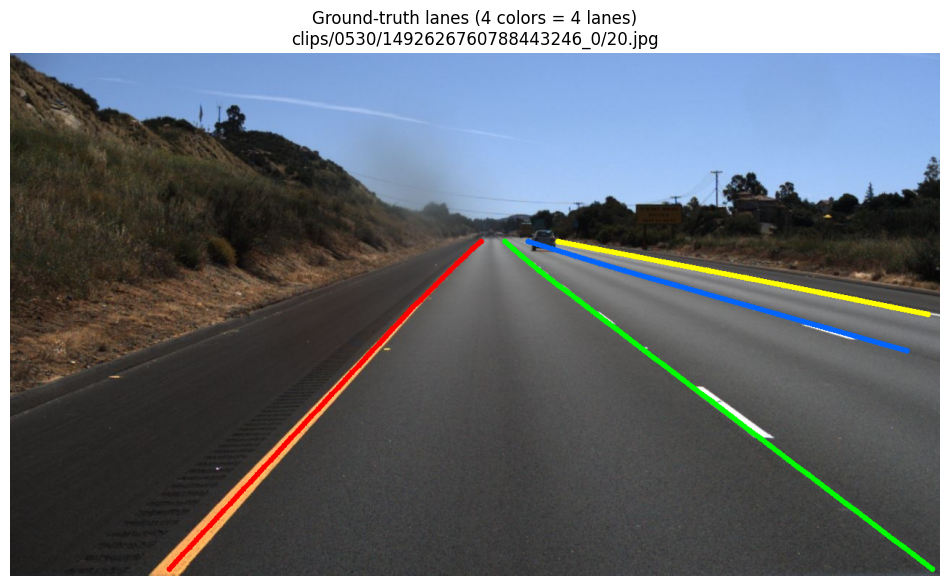

Visible lanes drawn: 4


In [5]:
def draw_lanes(image: np.ndarray, sample, thickness: int = 5) -> np.ndarray:
    """Draw the ground-truth lanes on a copy of the image.

    Each lane gets a different color so you can distinguish them.

    Args:
        image:     Input RGB image (numpy array).
        sample:    A LaneAnnotation from our dataset.
        thickness: Line thickness in pixels.

    Returns:
        New image with lanes drawn.
    """
    # Work on a copy so we don't modify the original
    img = image.copy()

    # Distinct colors (RGB) for up to 5 lanes
    colors = [
        (255, 0, 0),    # red
        (0, 255, 0),    # green
        (0, 100, 255),  # blue
        (255, 255, 0),  # yellow
        (255, 0, 255),  # magenta
    ]

    for lane_idx, color in zip(range(sample.num_lanes), colors):
        # Get visible (x, y) points for this lane
        points = sample.get_lane_points(lane_idx)
        if len(points) < 2:
            continue  # Need at least 2 points to draw a line

        # Convert to NumPy array of int32 (cv2.polylines requires this)
        pts_array = np.array(points, dtype=np.int32)

        # Draw the lane as connected line segments
        # The False means "do not close the polyline" (we're drawing curves, not polygons)
        cv2.polylines(
            img,
            [pts_array],
            isClosed=False,
            color=color,
            thickness=thickness,
        )

        # Also draw small circles at each annotated point
        for x, y in points:
            cv2.circle(img, (x, y), radius=4, color=color, thickness=-1)

    return img


# Apply it
image_with_lanes = draw_lanes(image_rgb, sample)

plt.imshow(image_with_lanes)
plt.title(f"Ground-truth lanes (4 colors = 4 lanes)\n{sample.raw_file}")
plt.axis("off")
plt.show()

print(f"Visible lanes drawn: {sample.num_visible_lanes}")

## 6. Browse multiple samples

A single image is not representative — let's view a small grid to get a feel for the variety in the dataset. Notice:

- Different numbers of lanes (3 vs. 4) depending on the road
- Straight vs. curved roads
- Different lighting conditions (some shadowed, some bright)
- Different mountain/sky backgrounds

These variations are what our pipeline must be robust to.

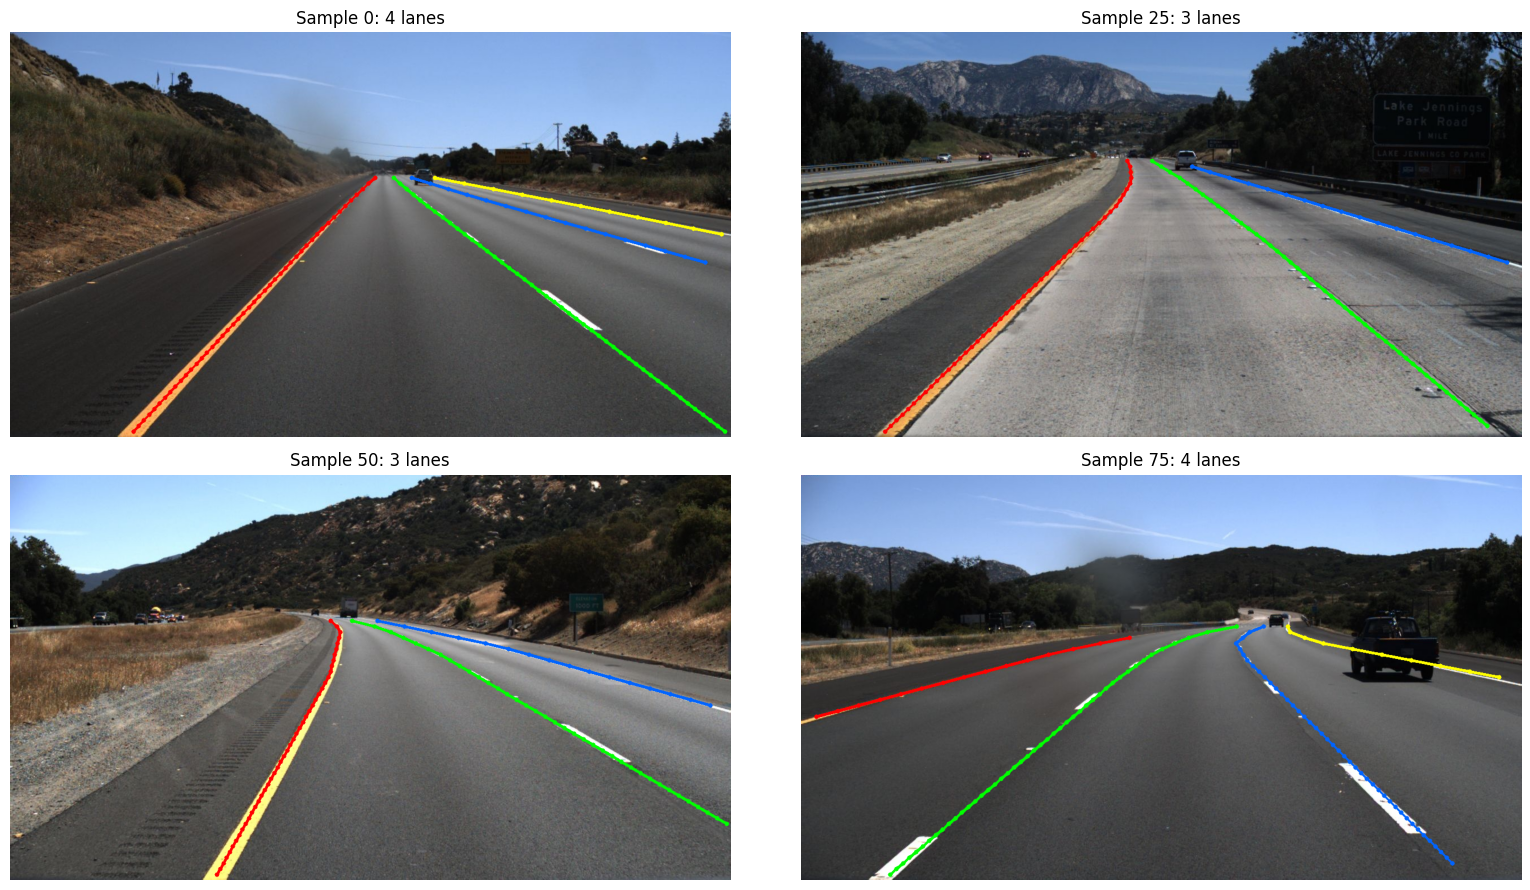

In [6]:
# Show 4 different samples in a grid
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, idx in zip(axes.flat, [0, 25, 50, 75]):
    sample = dataset[idx]
    img = cv2.imread(str(sample.image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = draw_lanes(img, sample, thickness=3)
    ax.imshow(img)
    ax.set_title(f"Sample {idx}: {sample.num_visible_lanes} lanes")
    ax.axis("off")

plt.tight_layout()
plt.show()